In [23]:
import pandas as pd

restaurants = pd.read_csv("Restaurant_Raw_Data.csv")
menu_categories = pd.read_csv("menu_categories.csv")
menu_items = pd.read_csv("menu_items.csv")

restaurants.head(35)

,Restaurant,Cuisine,Rating,Reviews,Cost_For_Two,Locality,Delivery_Time
0,La Pino'z Pizza,"Pizza, Italian",4.1,2.7K+,500,Krishi Nagar,35-40 mins
1,McDonald's,"Burgers, Beverages",4.4,2.8K+,400,Parijat Nagar,35-40 mins
2,Artisan,"Pizza, Fast Food",3.6,15,300,Vasant Market,35-40 mins
3,Pizza Hut,Pizza,4.3,8.4K+,300,College Road,40-45 mins
4,Domino's Pizza,"Pizza, Italian",3.9,9.2K+,700,College Road,20-25 mins
5,Burger King,"Burgers, American",4.3,39K+,350,Ramdas Colony,25-30 mins
6,KFC,"Burgers, Fast Food",4.1,97K+,400,College Road,49-54 mins
7,Luscious Layers,"Desserts, Cakes & Pastries",4.4,10K+,350,College Road,35-40 mins
8,Behrouz Biryani,"Biryani, North Indian",4.2,5.9K+,500,Thatte Nagar,30-35 mins
9,Dum Safar Biryani,"Biryani, Hyderabadi",4.0,1.7K+,500,City Centre,40-50 mins


In [24]:
import pandas as pd


# 1. Missing Values Check


query = """
SELECT *
FROM restaurants
WHERE restaurant_name IS NULL
   OR cuisine IS NULL
   OR rating IS NULL
   OR reviews IS NULL
   OR cost_for_two IS NULL
   OR delivery_time IS NULL
   OR locality IS NULL;
"""

missing_df = pd.read_sql(query, conn)

print("Missing Values Found:", len(missing_df))
missing_df

Missing Values Found: 0


C:\Users\deven\AppData\Local\Temp\ipykernel_23980\9517399.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  missing_df = pd.read_sql(query, conn)


,restaurant_id,restaurant_name,cuisine,rating,reviews,cost_for_two,delivery_time,locality


In [25]:

# 2. Duplicate Restaurants


query = """
SELECT restaurant_name,
       COUNT(*) AS frequency
FROM restaurants
GROUP BY restaurant_name
HAVING COUNT(*) > 1;
"""

duplicate_df = pd.read_sql(query, conn)

print("Duplicate Restaurants Found:", len(duplicate_df))
duplicate_df

Duplicate Restaurants Found: 0


C:\Users\deven\AppData\Local\Temp\ipykernel_23980\2652904900.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  duplicate_df = pd.read_sql(query, conn)


,restaurant_name,frequency


In [26]:

# 3. Invalid Ratings


query = """
SELECT *
FROM restaurants
WHERE rating < 0
   OR rating > 5;
"""

rating_df = pd.read_sql(query, conn)

print("Invalid Ratings Found:", len(rating_df))
rating_df

Invalid Ratings Found: 0


C:\Users\deven\AppData\Local\Temp\ipykernel_23980\2497454533.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rating_df = pd.read_sql(query, conn)


,restaurant_id,restaurant_name,cuisine,rating,reviews,cost_for_two,delivery_time,locality


In [27]:

# 4. Invalid Cost Values


query = """
SELECT *
FROM restaurants
WHERE cost_for_two <= 0;
"""

cost_df = pd.read_sql(query, conn)

print("Invalid Cost Records:", len(cost_df))
cost_df

Invalid Cost Records: 0


C:\Users\deven\AppData\Local\Temp\ipykernel_23980\2417574193.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cost_df = pd.read_sql(query, conn)


,restaurant_id,restaurant_name,cuisine,rating,reviews,cost_for_two,delivery_time,locality


In [28]:

# 5. Invalid Menu Prices


query = """
SELECT *
FROM menu_items
WHERE price <= 0;
"""

price_df = pd.read_sql(query, conn)

print("Invalid Menu Prices:", len(price_df))
price_df

Invalid Menu Prices: 0


C:\Users\deven\AppData\Local\Temp\ipykernel_23980\1488880937.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  price_df = pd.read_sql(query, conn)


,item_id,restaurant_name,menu_category,item_name,price


In [29]:

# 6. Review Standardization


query = """
SELECT restaurant_name,
       reviews,
       REPLACE(REPLACE(reviews,'K+','000'),'+','') AS reviews_clean
FROM restaurants;
"""

review_df = pd.read_sql(query, conn)

review_df.head(10)

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\1248146381.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  review_df = pd.read_sql(query, conn)


,restaurant_name,reviews,reviews_clean
0,La Pino'z Pizza,2.7K+,2.7000
1,McDonald's,2.8K+,2.8000
2,Artisan,15,15
3,Pizza Hut,8.4K+,8.4000
4,Domino's Pizza,9.2K+,9.2000
5,Burger King,39K+,39000
6,KFC,97K+,97000
7,Luscious Layers,10K+,10000
8,Behrouz Biryani,5.9K+,5.9000
9,Dum Safar Biryani,1.7K+,1.7000


## 7. Data Cleaning Summary

In [30]:

# 7. Data Cleaning Summary


summary = pd.DataFrame({
    "Check": [
        "Missing Values",
        "Duplicate Records",
        "Invalid Ratings",
        "Invalid Cost Values",
        "Invalid Menu Prices"
    ],
    "Issues Found": [
        len(missing_df),
        len(duplicate_df),
        len(rating_df),
        len(cost_df),
        len(price_df)
    ]
})

summary

,Check,Issues Found
0,Missing Values,0
1,Duplicate Records,0
2,Invalid Ratings,0
3,Invalid Cost Values,0
4,Invalid Menu Prices,0


In [31]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Devendra@2901",
    database="swiggy_analysis"
)

cursor = conn.cursor()

### Top Rated Restaurants

In [33]:
query = """
SELECT restaurant_name, rating, reviews
FROM restaurants
ORDER BY rating DESC
LIMIT 10;
"""

import pandas as pd

df = pd.read_sql(query, conn)
df

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\1498374090.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,restaurant_name,rating,reviews
0,Nashik Coffee House,4.8,4
1,Shegaon Kachori Centre,4.6,122
2,Hotel Durga,4.6,1.8K+
3,Hotel Inayat Cafe,4.5,36K+
4,Hotel Yahoo,4.5,12K+
5,Nadbrahma Idli,4.5,436
6,McDonald's,4.4,2.8K+
7,Mughal Darbar,4.4,5K+
8,Curry Leaves,4.4,18K+
9,Luscious Layers,4.4,10K+


### Cost for two or Most expensive top 10 restaurants

In [34]:
query = """
SELECT restaurant_name, cost_for_two
FROM restaurants
ORDER BY cost_for_two DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)
df

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\3145503827.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,restaurant_name,cost_for_two
0,Domino's Pizza,700
1,Hotel Yahoo,650
2,Barbeque Nation,600
3,La Pino'z Pizza,500
4,Behrouz Biryani,500
5,Dum Safar Biryani,500
6,Hakka Tikka,450
7,Kaka Ka Dhaba,450
8,McDonald's,400
9,KFC,400


### Cheapest Restaurants

In [35]:
query = """
SELECT restaurant_name, cost_for_two
FROM restaurants
ORDER BY cost_for_two ASC
LIMIT 10;
"""

df = pd.read_sql(query, conn)
df

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\1797681389.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,restaurant_name,cost_for_two
0,Raman Loni Sponge Dosa Center,100
1,Nadbrahma Idli,100
2,Shegaon Kachori Centre,150
3,Hotel Durga,200
4,Hotel Krishna Leela Family Restaurant,200
5,Anna's House of Dosa,200
6,Nashik Coffee House,200
7,Thakur Ji,200
8,Grill Chinese,200
9,Shree Sadguru Pure Veg Chinese,250


### Average Rating by Cuisine

In [36]:
query = """
SELECT cuisine,
       ROUND(AVG(rating),2) AS avg_rating
FROM restaurants
GROUP BY cuisine
ORDER BY avg_rating DESC;
"""

df = pd.read_sql(query, conn)
df

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\1442125460.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,cuisine,avg_rating
0,North Indian,4.80
1,"South Indian, Sandwich",4.60
2,"Snacks, Maharashtrian",4.60
3,"South Indian, Indian",4.50
4,"North Indian, Tandoor",4.50
5,"Burgers, Beverages",4.40
6,"Desserts, Cakes & Pastries",4.40
7,"Snacks, Chinese",4.40
8,"Mughlai, Biryani",4.40
9,"North Indian, Biryani",4.40


### Average Cost for Two

In [37]:
query = """
SELECT ROUND(AVG(cost_for_two),2) AS avg_cost
FROM restaurants;
"""

df = pd.read_sql(query, conn)
df

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\3136796925.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,avg_cost
0,338.24


### Average Delivery Time

In [38]:
query = """
SELECT delivery_time,
       COUNT(*) AS total_restaurants
FROM restaurants
GROUP BY delivery_time;
"""

df = pd.read_sql(query, conn)
df

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\2570478730.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,delivery_time,total_restaurants
0,35-40 mins,13
1,40-45 mins,5
2,20-25 mins,1
3,25-30 mins,1
4,49-54 mins,1
5,30-35 mins,3
6,40-50 mins,3
7,30-40 mins,2
8,35-45 mins,2
9,45-55 mins,3


### Number of Categories Per Restaurant

In [39]:
query = """
SELECT restaurant_name,
       COUNT(*) AS total_categories
FROM menu_categories
GROUP BY restaurant_name
ORDER BY total_categories DESC;
"""

df = pd.read_sql(query, conn)
df

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\1463598438.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,restaurant_name,total_categories
0,KFC,5
1,Anna's House of Dosa,5
2,Dominos Pizza,3
3,Burger King,3
4,Behrouz Biryani,2


### Most Expensive Menu Items

In [40]:
query = """
SELECT restaurant_name,
       item_name,
       price
FROM menu_items
ORDER BY price DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)
df

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\4120169304.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,restaurant_name,item_name,price
0,Dominos Pizza,Big Big 6in1 Cheeseburst Veg,899
1,Dominos Pizza,Big Big 6in1 Pizza Veg,799
2,KFC,Wednesday Chicken Bucket,798
3,KFC,Wednesday Chicken Strips Bucket,649
4,Dominos Pizza,Cheese Burst Peppy Paneer Xtravaganza Meal,609
5,Dominos Pizza,Cheese Burst Veggie Paradise Xtravaganza Meal,609
6,Behrouz Biryani,Hyderabadi Dum Gosht Biryani,599
7,Dominos Pizza,Classic Pepper BBQ Chicken Xtravaganza Meal,579
8,KFC,Wednesday Value Special Chicken Bucket,549
9,Dominos Pizza,Classic Peppy Paneer Xtravaganza Meal,539


### Average Item Price by Restaurant

In [41]:
query = """
SELECT restaurant_name,
       ROUND(AVG(price),2) AS avg_price
FROM menu_items
GROUP BY restaurant_name
ORDER BY avg_price DESC;
"""

df = pd.read_sql(query, conn)
df

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\2356499663.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,restaurant_name,avg_price
0,Dominos Pizza,569.60
1,Behrouz Biryani,444.00
2,KFC,359.89
3,Burger King,144.00
4,Anna's House of Dosa,128.09


C:\Users\deven\AppData\Local\Temp\ipykernel_23980\1471538723.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


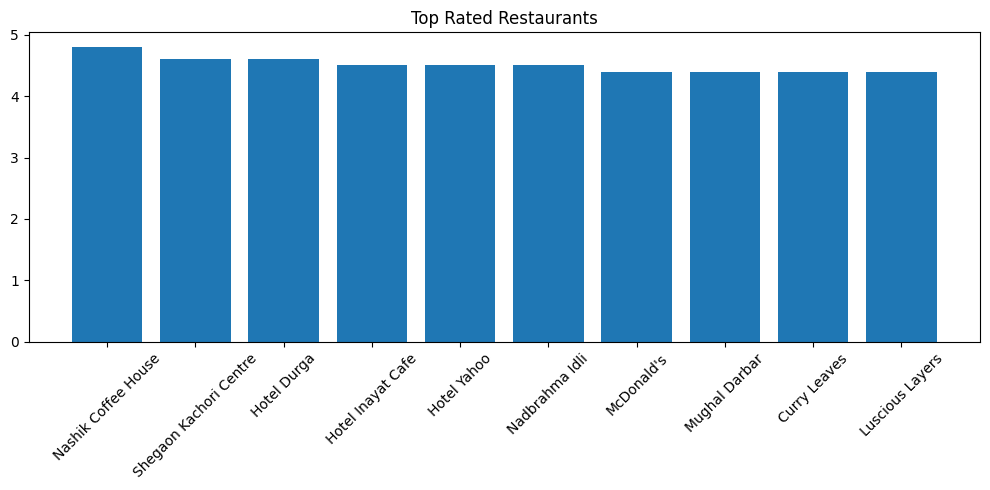

In [44]:
import matplotlib.pyplot as plt

query = """
SELECT restaurant_name, rating
FROM restaurants
ORDER BY rating DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
plt.bar(df['restaurant_name'], df['rating'])
plt.xticks(rotation=45)
plt.title('Top Rated Restaurants')
plt.tight_layout()
plt.show()

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\1185110927.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


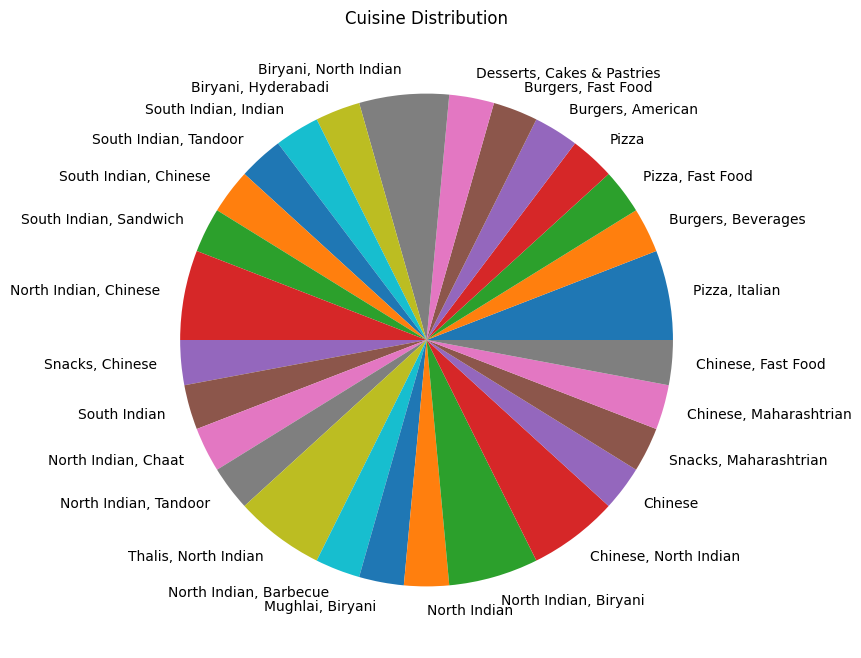

In [45]:
query = """
SELECT cuisine, COUNT(*) as total
FROM restaurants
GROUP BY cuisine;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(8,8))
plt.pie(df['total'], labels=df['cuisine'])
plt.title('Cuisine Distribution')
plt.show()

C:\Users\deven\AppData\Local\Temp\ipykernel_23980\367541129.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


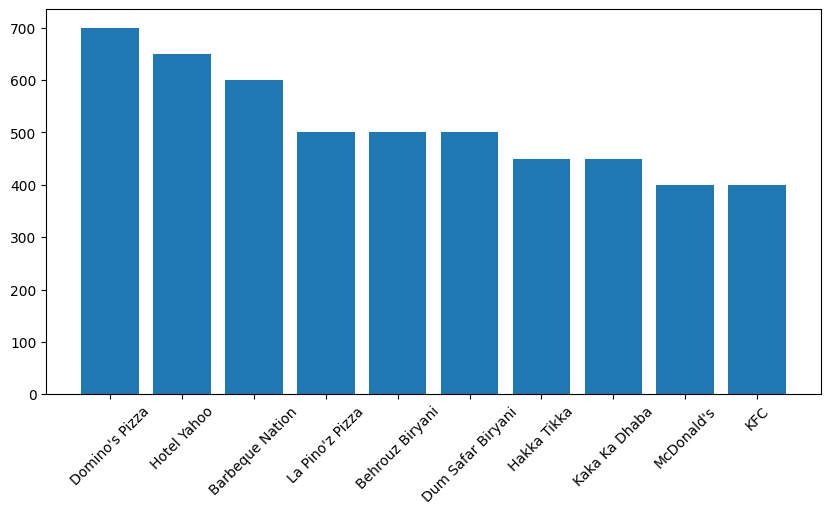

In [46]:
query = """
SELECT restaurant_name,cost_for_two
FROM restaurants
ORDER BY cost_for_two DESC
LIMIT 10;
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
plt.bar(df['restaurant_name'],df['cost_for_two'])
plt.xticks(rotation=45)
plt.show()